# Induction Eval — Results Analysis
Loads the YAML result files produced by `induction_eval.ipynb` and plots
accuracy for each (model × context-type) combination in a single figure.

In [7]:
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from smolbench.evals import Marks

RESULTS_DIR = Path("results")


def load_marks(path: Path) -> Marks:
    with open(path) as f:
        return yaml.unsafe_load(f)


def accuracy(marks: Marks) -> float:
    """Correct / (correct + incorrect + invalid)."""
    total = marks.correct + marks.incorrect + marks.invalid
    return marks.correct / total if total > 0 else 0.0


# (model_key, condition_key) -> result file
FILES = {
    ("decode", "intens"):        "decode_intens.yaml",
    ("decode", "extens"):        "decode_extens.yaml",
    ("decode", "noise_intens"):  "decode_noise_intens.yaml",
    ("cot",    "intens"):        "cot_intens.yaml",
    ("cot",    "extens"):        "cot_extens.yaml",
    ("cot",    "noise_intens"):  "cot_noise_intens.yaml",
    ("moe",    "intens"):        "moe_intens.yaml",
    ("moe",    "extens"):        "moe_extens.yaml",
    ("moe",    "noise_intens"):  "moe_noise_intens.yaml",
}

data: dict[tuple[str, str], float | None] = {}
for (model_key, cond_key), fname in FILES.items():
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        data[(model_key, cond_key)] = accuracy(load_marks(fpath))
    else:
        data[(model_key, cond_key)] = None
        print(f"Missing result file: {fpath}")

data

{('decode', 'intens'): 0.65,
 ('decode', 'extens'): 0.5833333333333334,
 ('decode', 'noise_intens'): 0.5083333333333333,
 ('cot', 'intens'): 0.7166666666666667,
 ('cot', 'extens'): 0.6583333333333333,
 ('cot', 'noise_intens'): 0.6083333333333333,
 ('moe', 'intens'): 0.675,
 ('moe', 'extens'): 0.6166666666666667,
 ('moe', 'noise_intens'): 0.6083333333333333}

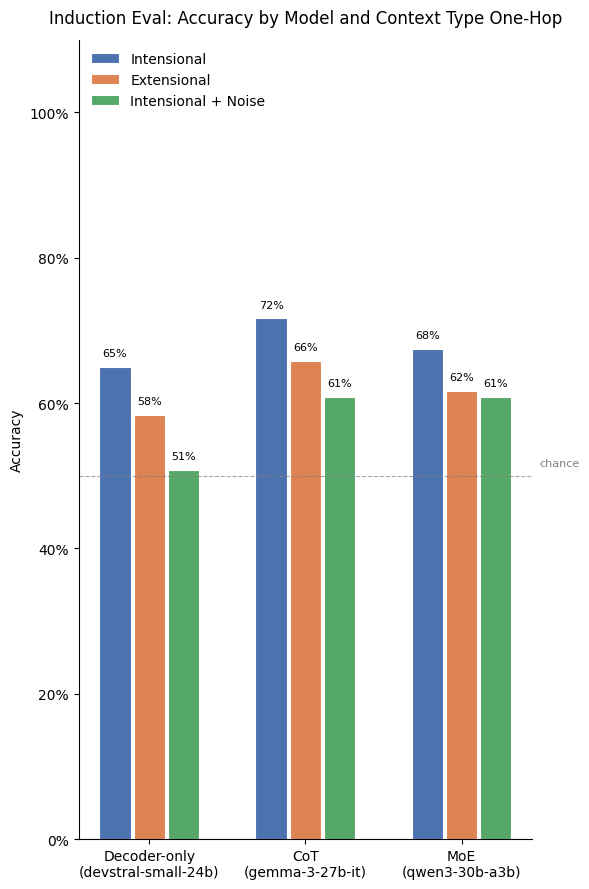

In [ ]:
MODELS = [
    ("decode", "Decoder-only\n(devstral-small-24b)"),
    ("cot",    "CoT\n(gemma-3-27b-it)"),
    ("moe",    "MoE\n(qwen3-30b-a3b)"),
]

CONDITIONS = [
    ("intens",       "Intensional",           "#4C72B0"),
    ("extens",       "Extensional",           "#DD8452"),
    ("noise_intens", "Intensional + Noise",   "#55A868"),
]

x = np.arange(len(MODELS))
bar_w = 0.22
offsets = np.array([-1, 0, 1]) * bar_w

fig, ax = plt.subplots(figsize=(6, 9))

for offset, (cond_key, cond_label, color) in zip(offsets, CONDITIONS):
    heights = [
        data.get((model_key, cond_key)) or 0.0
        for model_key, _ in MODELS
    ]
    bars = ax.bar(
        x + offset, heights, bar_w - 0.02,
        label=cond_label, color=color, edgecolor="white", linewidth=0.8,
    )
    for bar, h in zip(bars, heights):
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.012,
                f"{h:.0%}",
                ha="center", va="bottom", fontsize=8,
            )

# 50 % chance-level reference line
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.text(len(MODELS) - 0.5, 0.51, "chance", color="grey", fontsize=8, va="bottom")

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in MODELS])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Induction Eval: Accuracy by Model and Context Type NIAH", pad=12)
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("induction_eval_results.png", dpi=150, bbox_inches="tight")
plt.show()